=== Last weights (effective, after leverage if any) ===
511010    1.2500
510880    0.0922
518880    0.0597
510300    0.0501
510500    0.0391
159915    0.0295
Name: 2026-01-16 00:00:00, dtype: float64

=== Performance summary ===
{'CAGR': 0.08708990384756543, 'Vol': 0.059453437481404636, 'Sharpe': 1.4240850094138218, 'MaxDD': -0.08791217300294474}
strategy start on:  2017-01-23 00:00:00

=== Backtset head/tail ===
            port_ret  nav
Date                     
2016-01-06       NaN  1.0
2016-01-07       NaN  1.0
2016-01-08       NaN  1.0
2016-01-11       NaN  1.0
2016-01-12       NaN  1.0
            port_ret       nav
Date                          
2026-01-16 -0.000136  2.052755
2026-01-19  0.001313  2.055450
2026-01-20  0.001601  2.058740
2026-01-21  0.001943  2.062740
2026-01-22  0.000000  2.062740


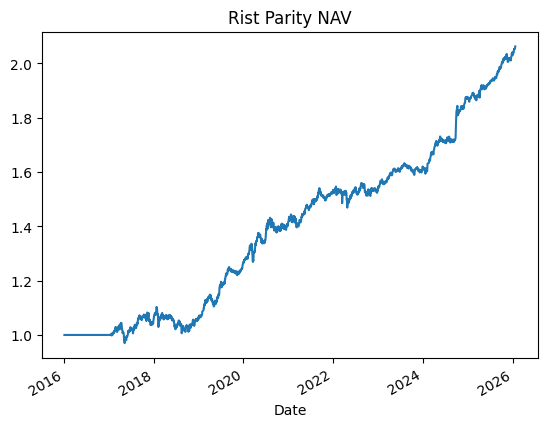

In [ ]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from scipy.optimize import minimize
import matplotlib.pyplot as plt
# 1) 风险平价：核心数学实现

def portfolio_vol(cov: np.ndarray, w: np.ndarray) -> float:
    """组合波动率: sqrt(w^T Σ w).  Σ 建议用年化协方差。"""
    R_w = w.T @ cov @ w#cov：协方差矩阵，w：权重
    sigma = float(np.sqrt(R_w))#sigma为波动率,与文中的风险平价对照一致
    return sigma

def risk_contributions(cov: np.ndarray, w: np.ndarray) -> np.ndarray:
    """
    按报告中的定义计算 TRC（总风险贡献）:
    TRC_i = w_i * (Σw)_i / sqrt(w^T Σ w)
    """
    s = cov @ w
    R_w = w.T @ cov @ w
    sigma = float(np.sqrt(R_w))
    return w * s / sigma

def risk_parity_weights_convex(cov: np.ndarray,budget: np.ndarray | None = None, eps: float = 1e-10) -> np.ndarray:
    """
    通过“等价凸优化”求解风险预算/风险平价权重（非负、自动 > 0）。
    
    常见的 Roncalli 等价凸目标（与报告“ln(w_i)”思路一致）：
        minimize_y  0.5 * y^T Σ y  -  sum_i b_i * ln(y_i)
        s.t.        y_i > 0
    解 y 只确定到一个比例因子，最后归一化得到 w = y / sum(y)。

    - budget b：风险预算（和为1）。风险平价就是 b_i = 1/N。
    - cov：建议输入年化协方差矩阵（例如日收益协方差 * 252）。
    """
    n = cov.shape[0]
    if budget is None:
        budget = np.ones(n) / n#未显式传参则直接默认全是1/n
    budget = np.array(budget, dtype=float)
    budget = budget / budget.sum()

    inv_var = 1.0 / np.clip(np.diag(cov), eps, None)#设置一个小下界保证数值稳定
    y0 = budget * inv_var
    y0 = np.clip(y0, eps, None)

    def obj(y: np.ndarray) -> float:
        y = np.clip(y, eps, None)
        return 0.5 * (y.T @ cov @ y) - float(np.dot(budget, np.log(y)))#ai说对目标函数稍作改动得到等价的优化问题，并且还可以加快跑的速度
    

    def grad(y: np.ndarray) -> np.ndarray:
        y = np.clip(y, eps, None)
        return cov @ y - budget / y#对目标函数的梯度

    bounds = [(eps, None)] * n
    
    res = minimize(obj, y0, jac=grad, method="L-BFGS-B", bounds=bounds, 
                   options={'maxiter' : 300, 'ftol' : 1e-9})#拟牛顿法优化
    if not res.success:#收敛判别
        raise RuntimeError(f"Optimization failed: {res.message}")#不收敛直接报错

    y = np.clip(res.x, eps, None)
    w = y / y.sum()
    return w

# 2) 回测框架（滚动协方差 + 月度调仓）

@dataclass(frozen=True)
class BacktestConfig:
    lookback_days: int = 252#用过去1年估协方差
    rebalance_freq: str = "W-FRI"#月末调仓
    annualization: int = 252#日频年化系数
    target_vol: float | None = None#目标年化波动率（None=不加杠杆）
    max_leverage: float = 2.0#杠杆上限（仅在 target_vol 非空时生效）
    
    boundary_ticker : str = '511010'
    boundary_511010 : float = 1.25
    

def load_prices_csv(path: str) -> pd.DataFrame:
    """
    读取价格表：
    - 第一列为日期或名为 Date
    - 其余列为各资产价格（建议 Adj Close）
    """
    if path.lower().endswith(('.xlsx','xls')):
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.set_index("Date")
    else:
        df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0])
        df = df.set_index(df.columns[0])
    df = df.sort_index()
    df.columns = df.columns.map(str).str.strip()
    return df

def backtest_risk_parity(prices: pd.DataFrame,
                         cfg: BacktestConfig,
                         budget: np.ndarray | None = None) -> pd.DataFrame:
    """
    输出：
    - weights: 每次调仓的权重（含杠杆缩放后的“风险资产权重”）
    - nav: 组合净值（假设融资利率=0；若要更严谨可自行加入 rf 序列）
    """
    prices = prices.dropna(how="any")
    rets = prices.pct_change().dropna()#计算日收益率

    # 生成调仓日：用 resample 取周期末（例如月末）
    s0 = rets.iloc[:, 0].dropna()
    reb_dates = s0.groupby(pd.Grouper(freq='W-FRI')).apply(lambda x: x.index.max())
    reb_dates = pd.DatetimeIndex(reb_dates.dropna().unique()).sort_values()
    reb_dates = reb_dates[reb_dates < rets.index[-1]]

    weight_records = []
    port_ret = pd.Series(index=rets.index, dtype=float)

    for d in reb_dates:
        # 确保调仓日有收益数据
        if d not in rets.index:
            continue
        end_loc = rets.index.get_loc(d)
        start_loc = end_loc - cfg.lookback_days
        if start_loc < 0:
            continue  # 不足回看窗口则跳过

        window = rets.iloc[start_loc:end_loc]
        cov = window.cov().values * cfg.annualization  # 年化协方差

        # 1) 风险平价（或风险预算）权重（不含杠杆）
        w = risk_parity_weights_convex(cov, budget=budget)

        # 2) 可选：按目标波动率进行杠杆缩放
        lev = 1.0
        if cfg.target_vol is not None:
            est_vol = portfolio_vol(cov, w)
            if est_vol > 0:
                lev = np.clip(cfg.target_vol / est_vol, 0.0, cfg.max_leverage)
        if cfg.boundary_ticker in rets.columns:#限制固收权重≤1.25
            i_bond = rets.columns.get_loc(cfg.boundary_ticker)
            w_bond = float(w[i_bond])
            if w_bond > 0:
                lev_cap = cfg.boundary_511010 / w_bond
                lev = min(lev, lev_cap)
            
        w_eff = w * lev  # 简化：把融资成本视为 0，组合收益直接按杠杆放大
        weight_records.append(pd.Series(w_eff, index=rets.columns, name=d))

        # 3) 将该权重应用到下一个调仓日前一天
        next_dates = reb_dates[reb_dates > d]
        end_date = next_dates[0] if len(next_dates) else rets.index[-1]
        seg = rets.loc[d:end_date].iloc[1:]
        port_ret.loc[seg.index] = seg.values @ w_eff

    weights = pd.DataFrame(weight_records).sort_index()
    nav = (1.0 + port_ret.fillna(0.0)).cumprod()
    out = pd.DataFrame({"port_ret": port_ret, "nav": nav})
    return out, weights


# 3) 简单绩效指标

def perf_summary(nav: pd.Series, annualization: int = 252) -> dict:
    r = nav.pct_change().dropna()
    if r.empty:
        return {}
    cagr = nav.iloc[-1] ** (annualization / len(r)) - 1
    vol = r.std() * np.sqrt(annualization)
    sharpe = (r.mean() * annualization) / (vol + 1e-12)
    dd = (nav / nav.cummax() - 1.0).min()
    return {"CAGR": float(cagr), "Vol": float(vol), "Sharpe": float(sharpe), "MaxDD": float(dd)}


# 4) 用法示例
if __name__ == "__main__":
    prices = load_prices_csv("指数收盘价2016-2026.xlsx")

    cfg = BacktestConfig(
        lookback_days=252,
        rebalance_freq="W-FRI",
        annualization=252,
        target_vol=0.10,     # 目标年化波动10%（不想加杠杆就设为 None）
        max_leverage=2.0
    )

    # 风险平价：budget=None 即等风险预算（每个资产风险占比相等）
    result, weights = backtest_risk_parity(prices, cfg, budget=None)
    

    print("=== Last weights (effective, after leverage if any) ===")
    print(weights.iloc[-1].sort_values(ascending=False).round(4))

    print("\n=== Performance summary ===")
    r_live = result['port_ret'].dropna()
    nav_live = (1.0  + r_live).cumprod()
    print(perf_summary(nav_live, annualization= cfg.annualization))
    print('strategy start on: ', r_live.index[0])
    
    print('\n=== Backtset head/tail ===')
    print(result.head())
    print(result.tail())
    
    result['nav'].plot(title='Rist Parity NAV')

    plt.show()
    
    